<a href="https://colab.research.google.com/github/darrpannn7/Teen_Smartphone_Usage_and_Addiction_Prediction/blob/main/Teen_Smartphone_Usage_and_Addiction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  Absolute Correlation of Each Feature with Addiction_Level
  Daily_Usage_Hours               0.4817  ✅ ≥0.03
  Apps_Used_Daily                 0.2636  ✅ ≥0.03
  Time_on_Social_Media            0.2395  ✅ ≥0.03
  Time_on_Gaming                  0.2313  ✅ ≥0.03
  Phone_Checks_Per_Day            0.2106  ✅ ≥0.03
  Sleep_Hours                     0.1956  ✅ ≥0.03
  Exercise_Hours                  0.0356  ✅ ≥0.03
  Age                             0.0355  ✅ ≥0.03
  Gender                          0.0272  ❌ below
  Self_Esteem                     0.0256  ❌ below
  Depression_Level                0.0249  ❌ below
  Phone_Usage_Purpose             0.0167  ❌ below
  Time_on_Education               0.0161  ❌ below
  Anxiety_Level                   0.0138  ❌ below
  Family_Communication            0.0131  ❌ below
  Weekend_Usage_Hours             0.0104  ❌ below
  Social_Interactions             0.0097  ❌ below
  Academic_Performance            0.0055  ❌ below
  Parental_Control                0.0040

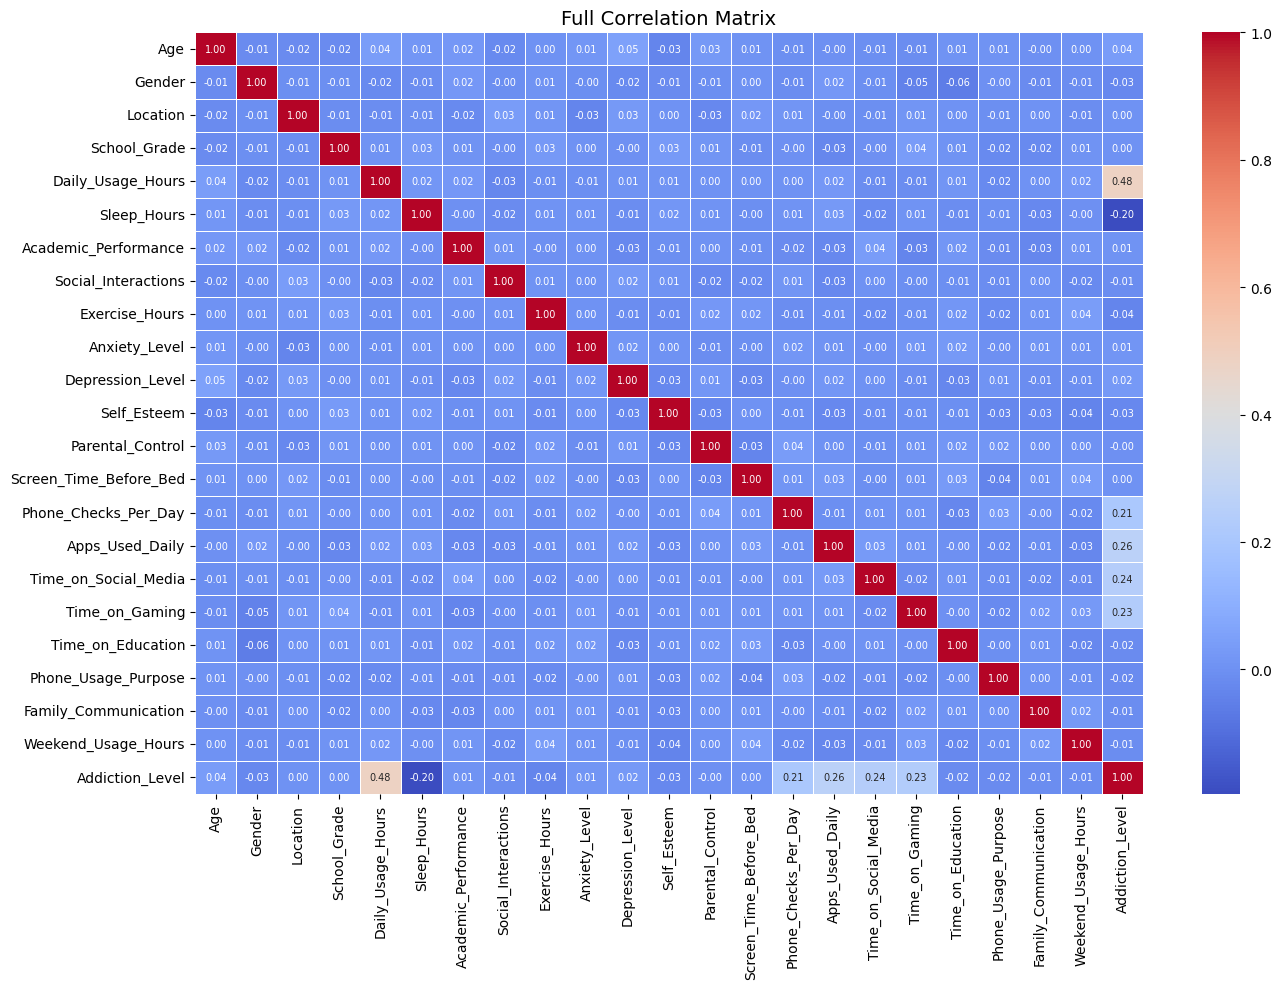

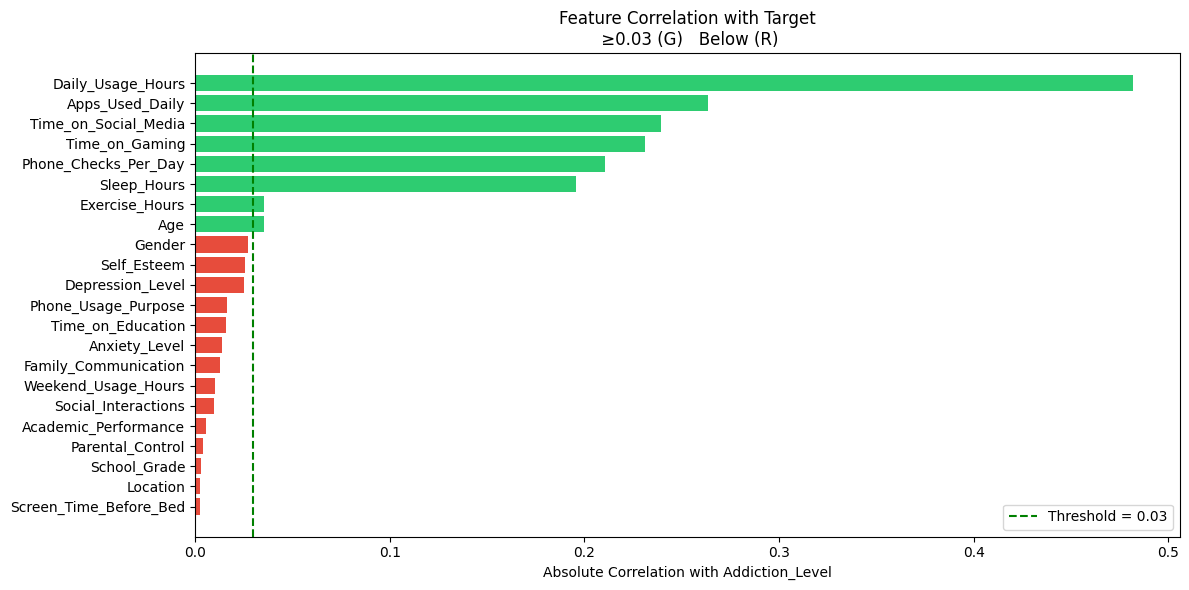


✅ Features with |corr| ≥ 0.03  →  8 features:
['Daily_Usage_Hours', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Phone_Checks_Per_Day', 'Sleep_Hours', 'Exercise_Hours', 'Age']


In [ ]:
# ✅ Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier

# ════════════════════════════════════════════════════════════════
# STEP 1 — Load & Prepare Data
# ════════════════════════════════════════════════════════════════
df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')
df.dropna(inplace=True)

# Drop identifier columns — no predictive value
df.drop(columns=['ID', 'Name'], inplace=True)

# Bin continuous Addiction_Level → 3 categories
df['Addiction_Level_Category'] = pd.cut(
    df['Addiction_Level'],
    bins=[-np.inf, 3.5, 7.5, np.inf],
    labels=[0, 1, 2]
)
df.drop(columns=['Addiction_Level'], inplace=True)
df.rename(columns={'Addiction_Level_Category': 'Addiction_Level'}, inplace=True)

# Drop rare classes
target_col = 'Addiction_Level'
class_counts = df[target_col].value_counts()
valid_classes = class_counts[class_counts >= 2].index
df = df[df[target_col].isin(valid_classes)]

# Encode all categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Convert target to int
df[target_col] = df[target_col].astype(int)

# ════════════════════════════════════════════════════════════════
# STEP 2 — Compute Correlation With Target & Print It
# ════════════════════════════════════════════════════════════════
correlation_with_target = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)          # exclude target correlating with itself
    .abs()                     # absolute value — direction doesn't matter for selection
    .sort_values(ascending=False)
)

print("=" * 55)
print("  Absolute Correlation of Each Feature with Addiction_Level")
print("=" * 55)
for feat, corr in correlation_with_target.items():
    tag = ""
    if corr >= 0.03:
        tag = "  ✅ ≥0.03"
    else:
        tag = "  ❌ below"
    print(f"  {feat:<30}  {corr:.4f}{tag}")
print("=" * 55)

# ════════════════════════════════════════════════════════════════
# STEP 3 — Plot Full Correlation Heatmap
# ════════════════════════════════════════════════════════════════
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.4, annot_kws={"size": 7}
)
plt.title("Full Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# ── Bar chart: correlation of each feature with target ──────────
plt.figure(figsize=(12, 6))
colors = ["#2ecc71" if v >= 0.03 else "#e74c3c"
          for v in correlation_with_target.values]
plt.barh(correlation_with_target.index[::-1],
         correlation_with_target.values[::-1],
         color=colors[::-1])
plt.axvline(0.03, color='green',  linestyle='--', linewidth=1.5, label='Threshold = 0.03')
plt.xlabel("Absolute Correlation with Addiction_Level")
plt.title("Feature Correlation with Target\n ≥0.03 (G)   Below (R)")
plt.legend()
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# STEP 4 — Select Features at Each Threshold
# ════════════════════════════════════════════════════════════════
features_03 = correlation_with_target[correlation_with_target >= 0.03].index.tolist()

print(f"\n✅ Features with |corr| ≥ 0.03  →  {len(features_03)} features:")
print(features_03)




Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level'],
      dtype='object')


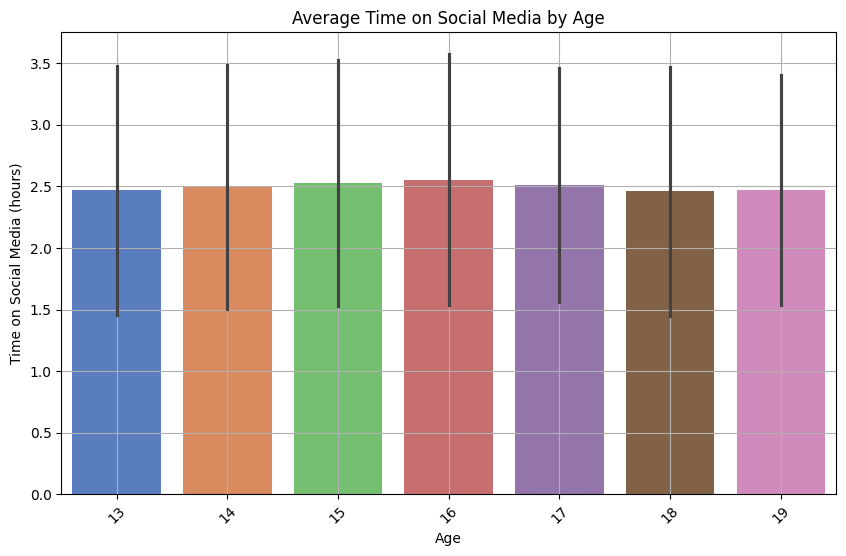

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')

# Check exact column name for social media time
print(df.columns)

# Replace 'Time on Social Media (hours)' with the exact column name if different
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Age', y='Time_on_Social_Media', ci='sd', palette='muted')
plt.title('Average Time on Social Media by Age')
plt.xlabel('Age')
plt.ylabel('Time on Social Media (hours)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

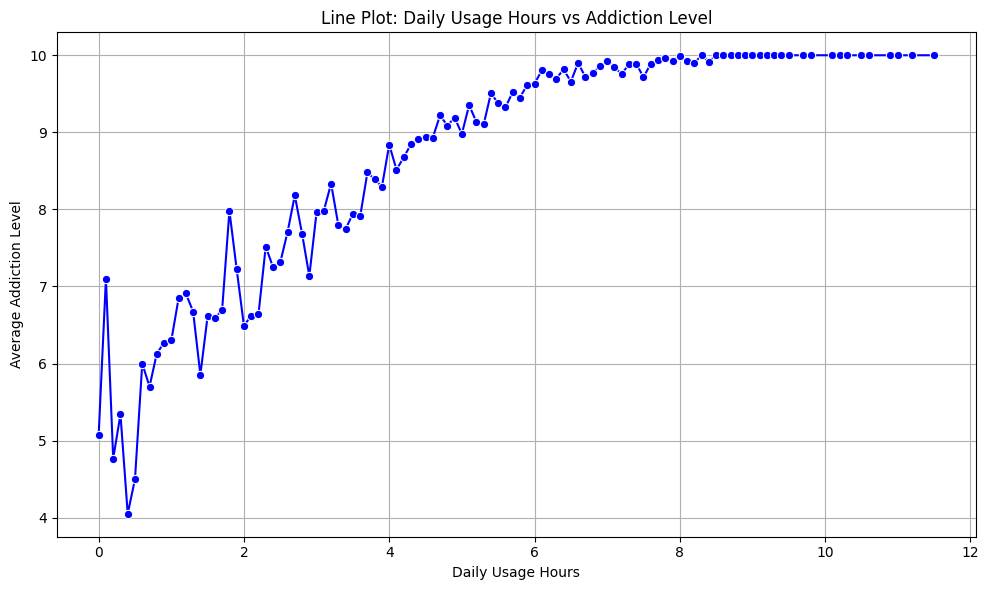

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')

# Grouping by Daily_Usage_Hours to get average Addiction_Level per usage hour
grouped_df = df.groupby('Daily_Usage_Hours')['Addiction_Level'].mean().reset_index()

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Daily_Usage_Hours', y='Addiction_Level', marker='o', color='blue')
plt.title('Line Plot: Daily Usage Hours vs Addiction Level')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Average Addiction Level')
plt.grid(True)
plt.tight_layout()
plt.show()

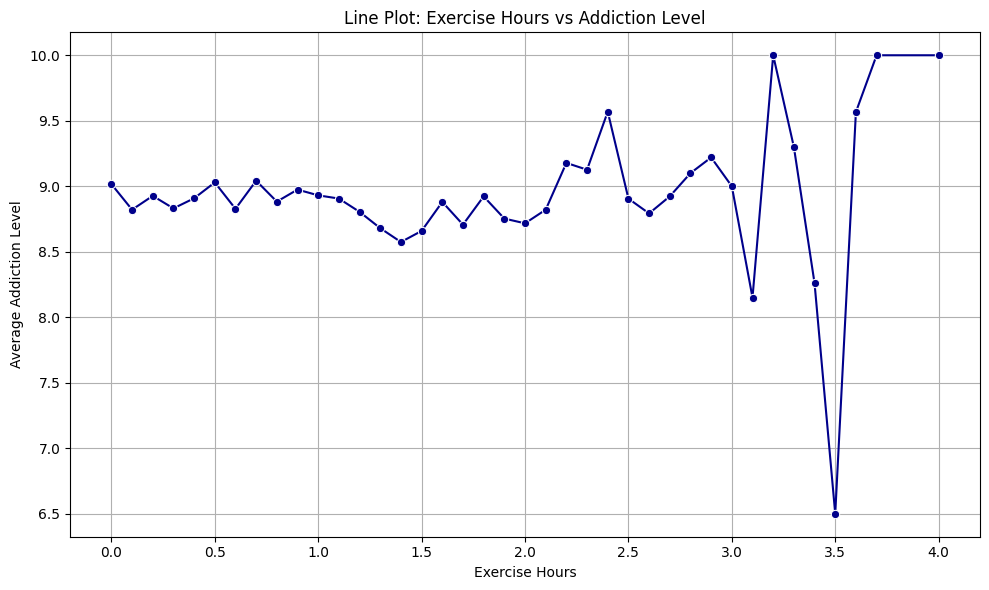

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')


# Group by Exercise_Hours to get average Addiction_Level
grouped_df = df.groupby('Exercise_Hours')['Addiction_Level'].mean().reset_index()

# Line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Exercise_Hours', y='Addiction_Level', marker='o', color='darkblue')
plt.title('Line Plot: Exercise Hours vs Addiction Level')
plt.xlabel('Exercise Hours')
plt.ylabel('Average Addiction Level')
plt.grid(True)
plt.tight_layout()
plt.show()

  Target variable statistics
count    3000.000
mean        8.882
std         1.610
min         1.000
25%         8.000
50%        10.000
75%        10.000
max        10.000
Name: Addiction_Level, dtype: float64
✅ |corr| ≥ 0.03  →  8 features : ['Daily_Usage_Hours', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Phone_Checks_Per_Day', 'Sleep_Hours', 'Gender', 'Age']


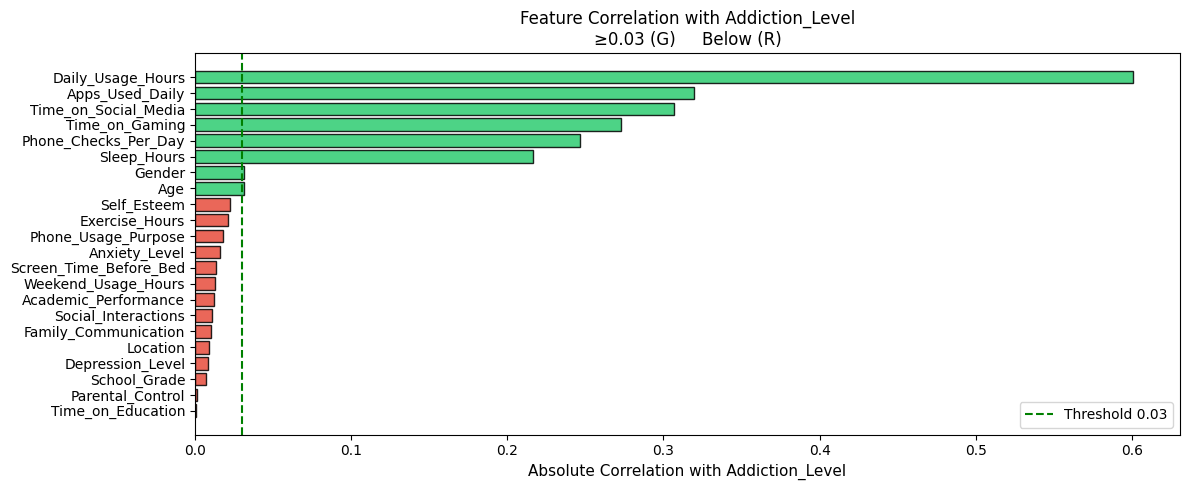


══════════════════════════════════════════════════════════════════════
  🚀 Threshold |corr| ≥ 0.03  |  8 features
  📋 ['Daily_Usage_Hours', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Phone_Checks_Per_Day', 'Sleep_Hours', 'Gender', 'Age']
══════════════════════════════════════════════════════════════════════

  🔍 Linear Regression
     [Holdout] RMSE=0.8138  MAE=0.6514  R²=0.7371  Acc@ε=0.0=0.0000  Acc@ε=0.3=0.2750  Acc@ε=0.5=0.4167
     [CV-5Fold ] RMSE=0.8234±0.0221  MAE=0.6612  R²=0.7379  Acc@ε=0.0=0.0000  Acc@ε=0.3=0.2613  Acc@ε=0.5=0.4123

  🔍 Decision Tree
     [Holdout] RMSE=0.8868  MAE=0.5153  R²=0.6879  Acc@ε=0.0=0.4317  Acc@ε=0.3=0.5383  Acc@ε=0.5=0.6600
     [CV-5Fold ] RMSE=0.8804±0.0292  MAE=0.5245  R²=0.6994  Acc@ε=0.0=0.4290  Acc@ε=0.3=0.5377  Acc@ε=0.5=0.6497

  🔍 SVR (C=1)
     [Holdout] RMSE=0.2234  MAE=0.1622  R²=0.9802  Acc@ε=0.0=0.0000  Acc@ε=0.3=0.8667  Acc@ε=0.5=0.9700
     [CV-5Fold ] RMSE=0.2212±0.0084  MAE=0.1605  R²=0.9811  Acc@ε=0.0=0.0000

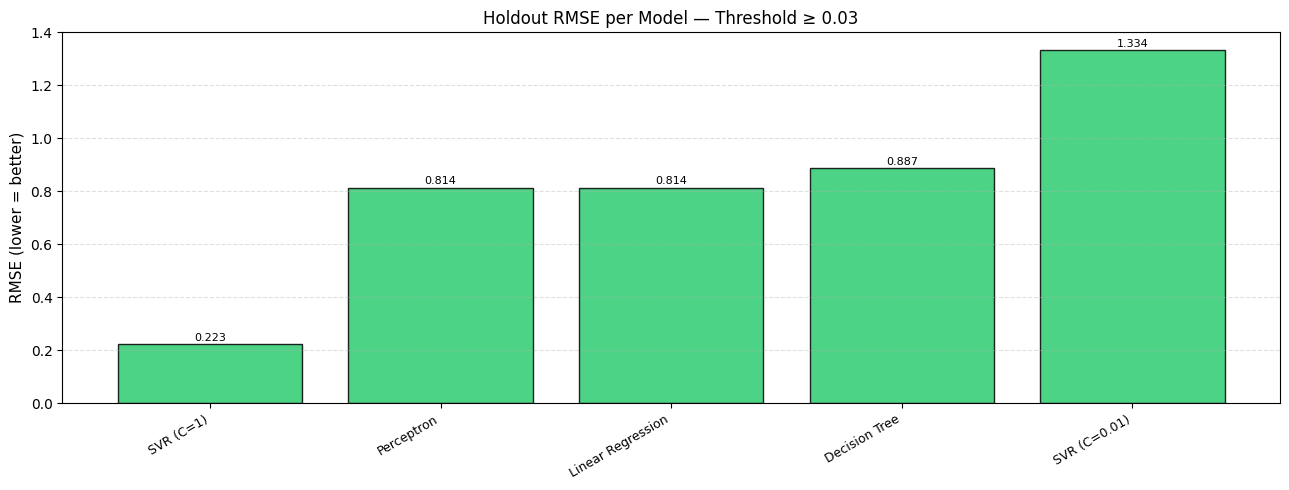

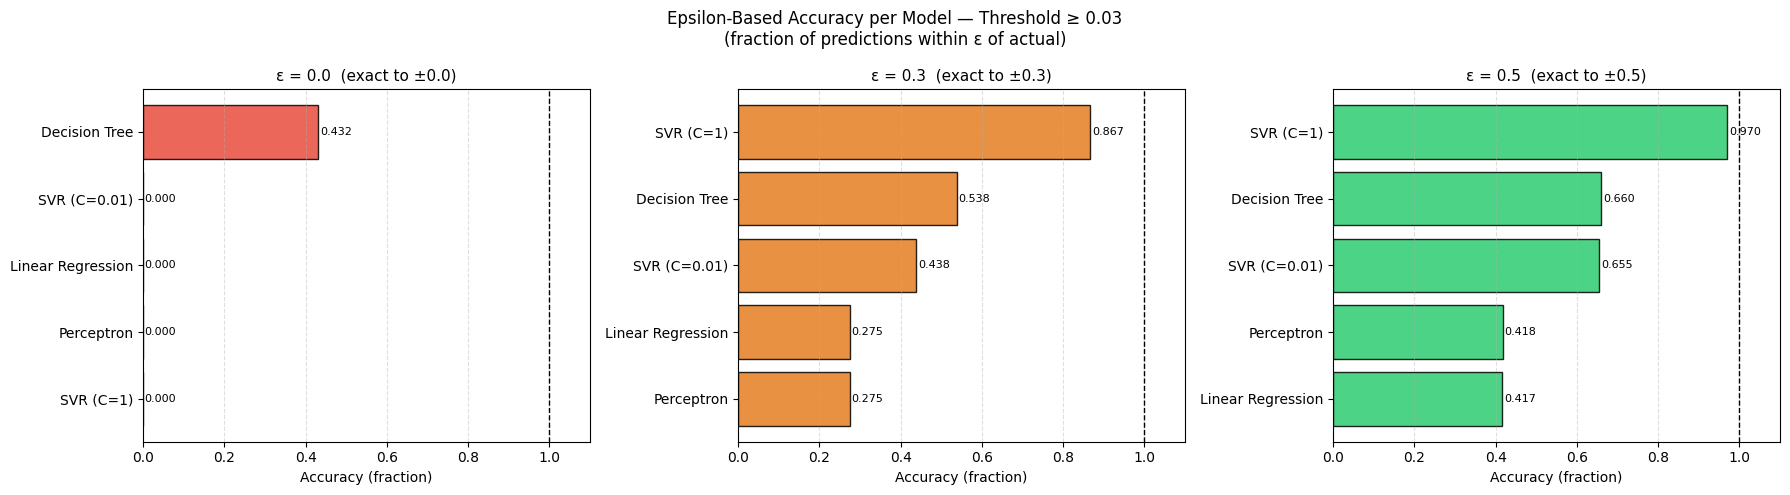

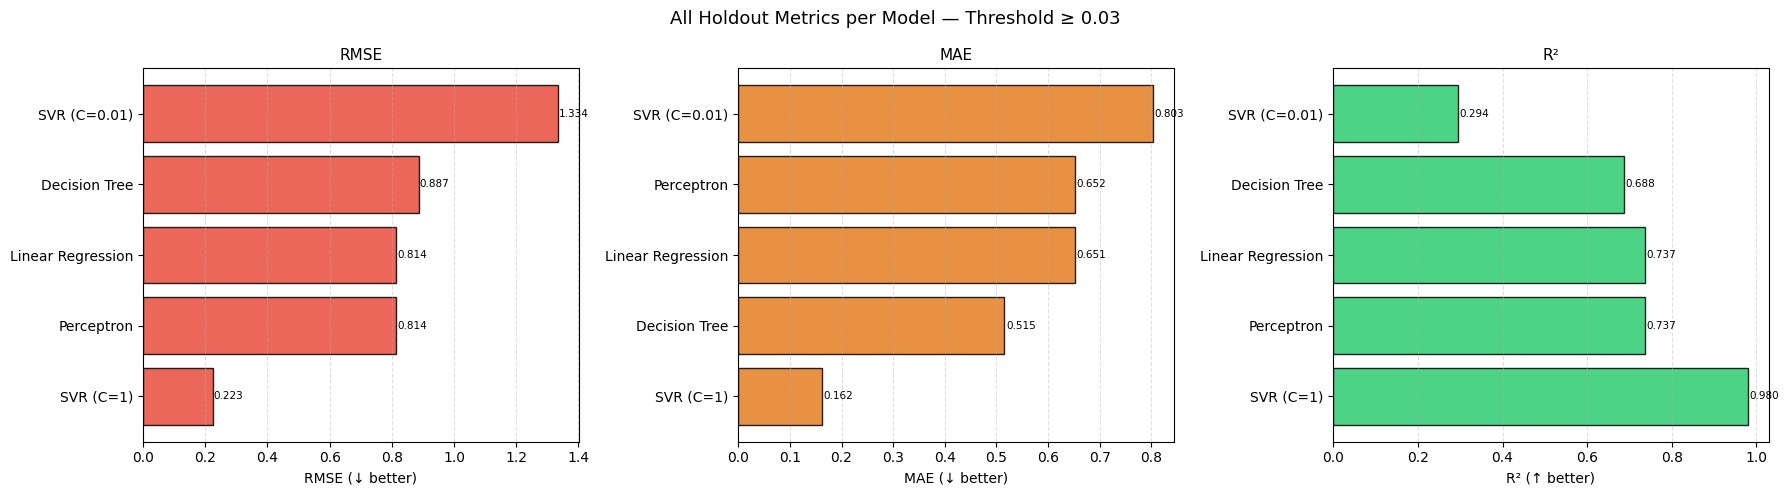

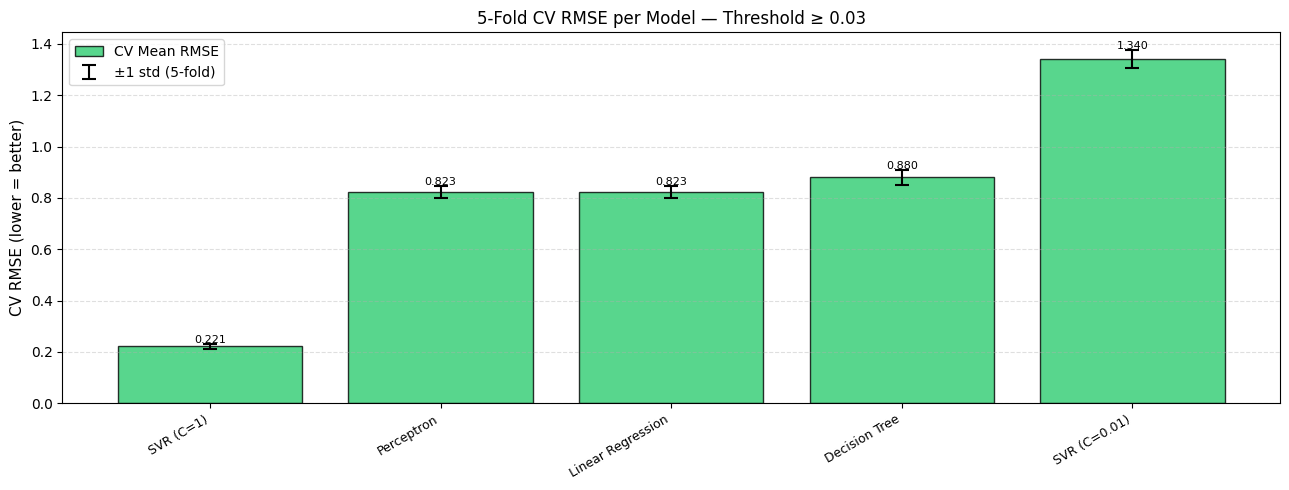

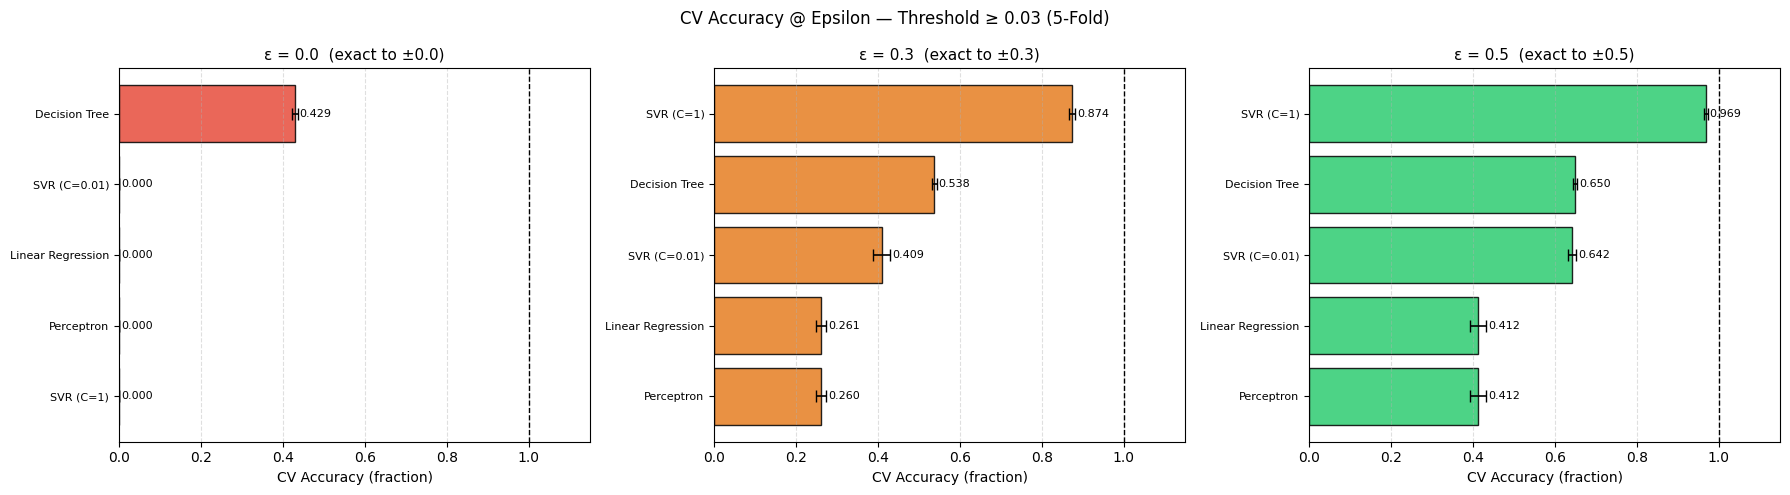

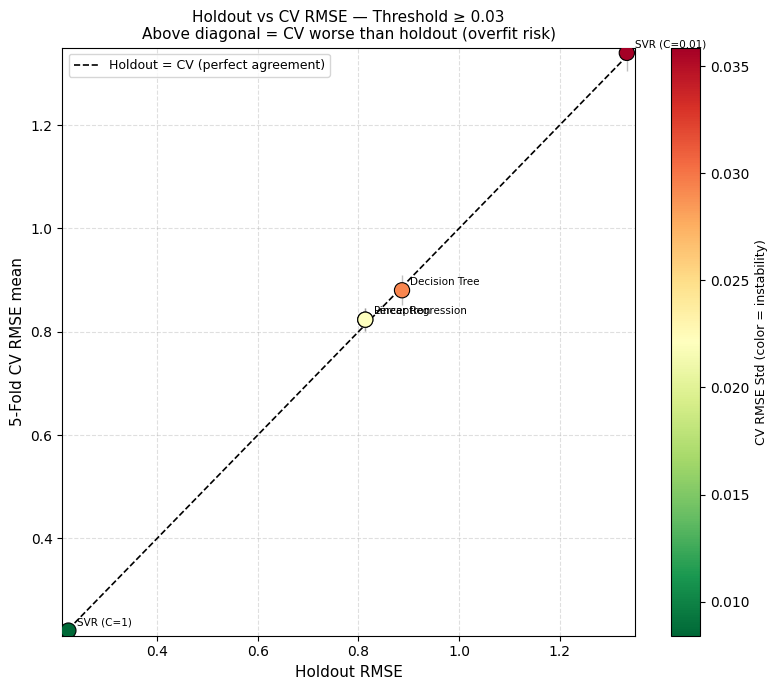

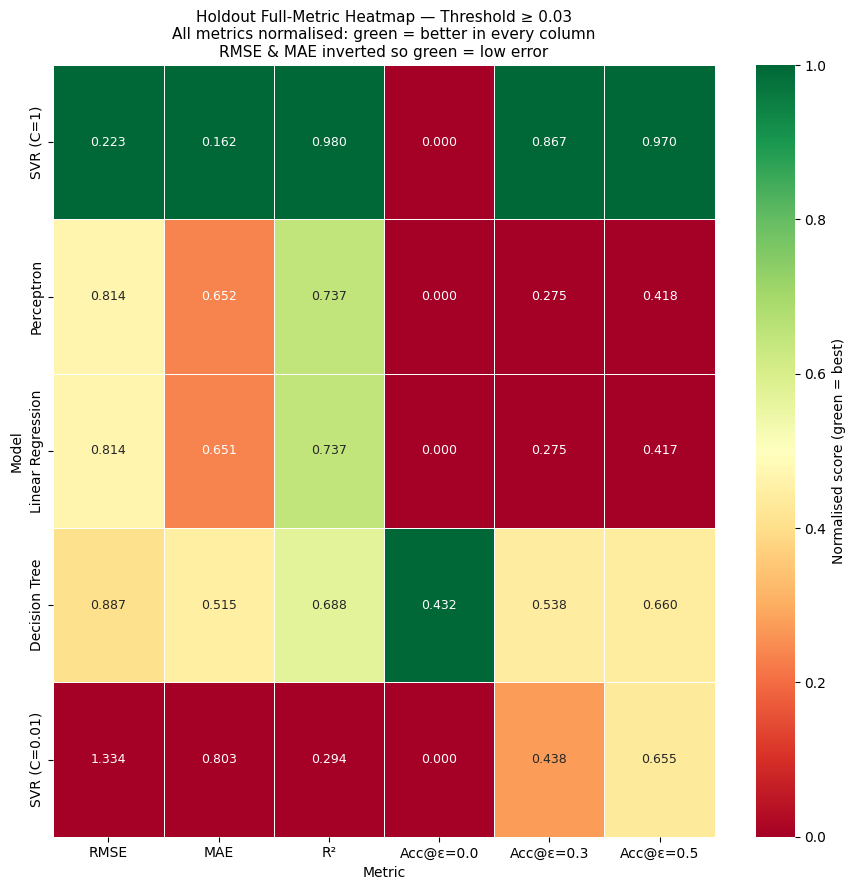

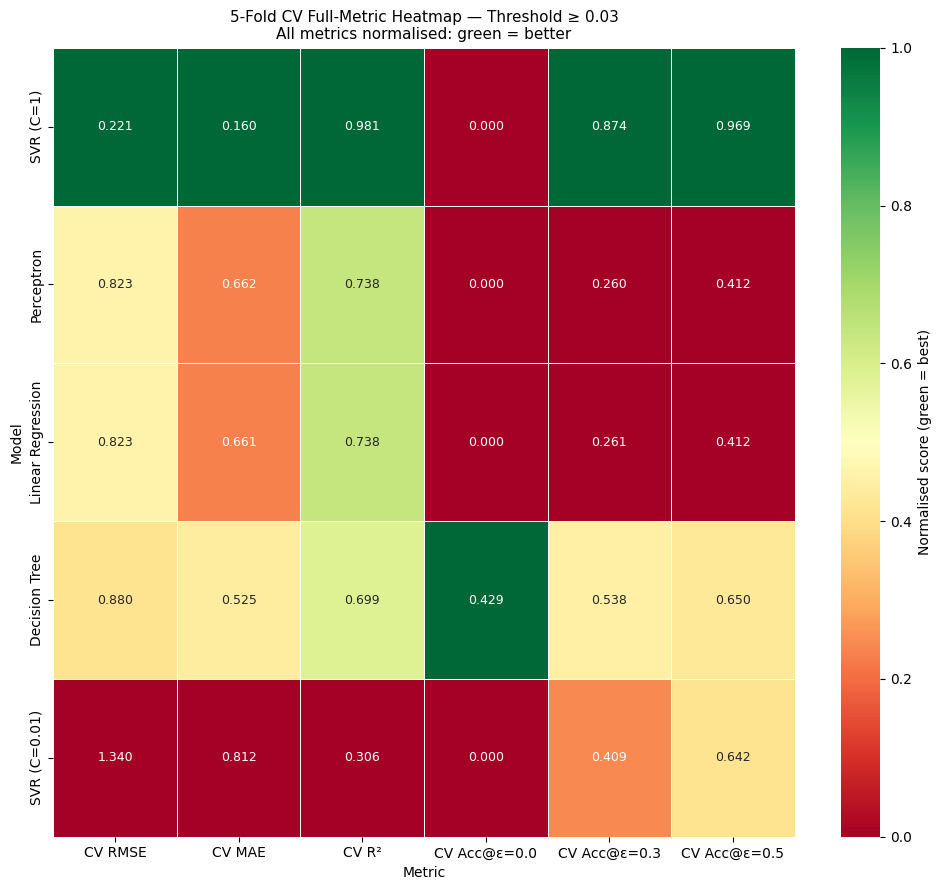

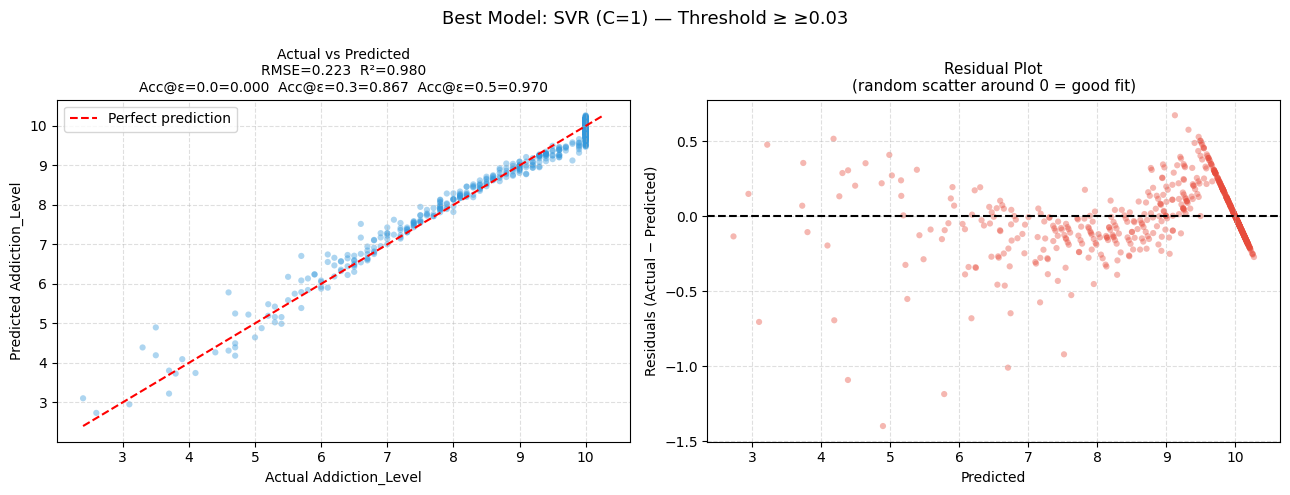

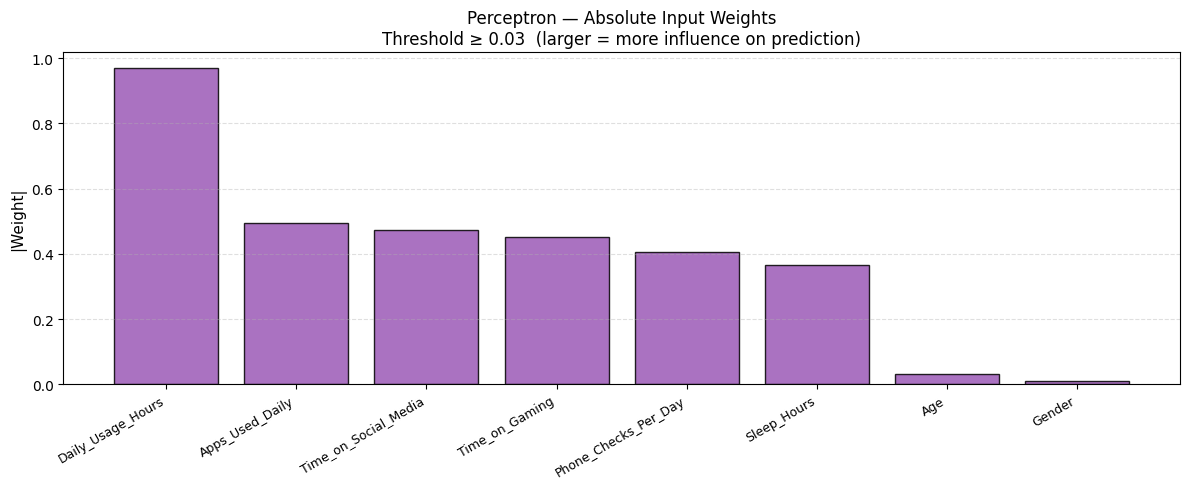

  • StandardScaler.fit() called ONLY on X_train
  • X_test is only .transform()-ed (no fit)
  • Each CV fold uses a fresh scaler fit on fold's train rows
  METRICS LEGEND:
   RMSE      — primary regression error (lower = better)
   MAE       — mean absolute error (lower = better)
   R²        — variance explained (closer to 1 = better)
   Acc@ε=0.0 — exact match (very strict)
   Acc@ε=0.3 — within 0.3 of true value
   Acc@ε=0.5 — within 0.5 of true value (most lenient)
  CV         — 5-fold cross-validation mean ± std
   Perceptron — MLPRegressor(hidden=(), activation=identity, solver=sgd)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  REGRESSION — Predict Addiction_Level (continuous)               ║
# ║  Metrics : RMSE, MAE, R², Accuracy@ε∈{0.0, 0.3, 0.5}             ║
# ║  Validation : Train/Test split  +  5-Fold Cross-Validation       ║
# ║  Feature subsets : |corr| ≥ 0.03                                 ║
# ╚══════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

EPSILONS     = [0.0, 0.3, 0.5]
N_SPLITS     = 5
RANDOM_STATE = 42

# ════════════════════════════════════════════════════════════════
# STEP 1 — Load & Prepare Data
# ════════════════════════════════════════════════════════════════
df = pd.read_csv('/content/teen_phone_addiction_dataset.csv')
df.dropna(inplace=True)
df.drop(columns=['ID', 'Name'], inplace=True, errors='ignore')

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

target_col = 'Addiction_Level'

print("=" * 55)
print("  Target variable statistics")
print("=" * 55)
print(df[target_col].describe().round(3))

# ════════════════════════════════════════════════════════════════
# STEP 2 — Correlation & Feature Selection
# ════════════════════════════════════════════════════════════════
corr = (df.corr(numeric_only=True)[target_col]
          .drop(target_col).abs()
          .sort_values(ascending=False))

features_03 = corr[corr >= 0.03].index.tolist()

print(f"✅ |corr| ≥ 0.03  →  {len(features_03)} features : {features_03}")

# ── Correlation bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if v >= 0.03 else "#e74c3c"
          for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1],
        color=colors[::-1], edgecolor='black', alpha=0.85)
ax.axvline(0.03, color='green',  linestyle='--', lw=1.5, label='Threshold 0.03')
ax.set_xlabel("Absolute Correlation with Addiction_Level", fontsize=11)
ax.set_title("Feature Correlation with Addiction_Level\n"
             "≥0.03 (G)     Below (R)", fontsize=12)
ax.legend(); plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# STEP 3 — Model Factory
# ════════════════════════════════════════════════════════════════
def get_regressors():
    return {
        "Linear Regression" : LinearRegression(),
        "Decision Tree"     : DecisionTreeRegressor(random_state=RANDOM_STATE),
        "SVR (C=1)"         : SVR(C=1.0,  kernel='rbf'),
        "SVR (C=0.01)"      : SVR(C=0.01, kernel='rbf'),
        "Perceptron"        : MLPRegressor(
                                  hidden_layer_sizes=(),
                                  activation='identity',
                                  solver='sgd',
                                  learning_rate='adaptive',
                                  max_iter=2000,
                                  random_state=RANDOM_STATE
                              ),
    }

# ════════════════════════════════════════════════════════════════
# HELPER — Compute all metrics from y_true / y_pred
# ════════════════════════════════════════════════════════════════
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    eps_acc = {eps: np.mean(np.abs(y_true - y_pred) <= eps)
               for eps in EPSILONS}
    return rmse, mae, r2, eps_acc

# ════════════════════════════════════════════════════════════════
# STEP 4 — Train / Test  +  K-Fold CV  Evaluation
# ════════════════════════════════════════════════════════════════
def train_and_evaluate(feature_list, threshold_label):
    print(f"\n{'═'*70}")
    print(f"  🚀 Threshold |corr| ≥ {threshold_label}  |  {len(feature_list)} features")
    print(f"  📋 {feature_list}")
    print(f"{'═'*70}")

    X = df[feature_list].values
    y = df[target_col].values

    # ── STEP A: Clean Holdout Split ───────────────────────────────
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)

    # ✅ FIX: Fit scaler ONLY on training data, transform test separately
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # learns mean/std from train only
    X_test  = scaler.transform(X_test_raw)         # applies train stats to test

    # ── STEP B: K-Fold setup on RAW X (scaler applied per fold below) ─
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    hold_records = []
    cv_records   = []

    for name, model in get_regressors().items():
        # ── Holdout evaluation ──────────────────────────────────
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse, mae, r2, eps_acc = compute_metrics(y_test, y_pred)

        hold_records.append({
            "Model"  : name,
            "RMSE"   : rmse,
            "MAE"    : mae,
            "R²"     : r2,
            **{f"Acc@ε={e}" : eps_acc[e] for e in EPSILONS},
            "y_pred" : y_pred,
        })

        # ── K-Fold CV: fresh scaler per fold — zero leakage ─────
        fold_rmse, fold_mae, fold_r2 = [], [], []
        fold_eps = {e: [] for e in EPSILONS}

        for tr_idx, val_idx in kf.split(X):     # split on RAW unscaled X
            # ✅ FIX: New scaler per fold, fit only on fold's training rows
            fold_scaler = StandardScaler()
            X_fold_train = fold_scaler.fit_transform(X[tr_idx])   # fit on fold train
            X_fold_val   = fold_scaler.transform(X[val_idx])       # transform fold val

            m_clone = get_regressors()[name]
            m_clone.fit(X_fold_train, y[tr_idx])
            yp = m_clone.predict(X_fold_val)
            r, a, s, ea = compute_metrics(y[val_idx], yp)
            fold_rmse.append(r); fold_mae.append(a); fold_r2.append(s)
            for e in EPSILONS: fold_eps[e].append(ea[e])

        cv_records.append({
            "Model"         : name,
            "CV_RMSE_mean"  : np.mean(fold_rmse),
            "CV_RMSE_std"   : np.std(fold_rmse),
            "CV_MAE_mean"   : np.mean(fold_mae),
            "CV_MAE_std"    : np.std(fold_mae),
            "CV_R²_mean"    : np.mean(fold_r2),
            "CV_R²_std"     : np.std(fold_r2),
            **{f"CV_Acc@ε={e}_mean" : np.mean(fold_eps[e]) for e in EPSILONS},
            **{f"CV_Acc@ε={e}_std"  : np.std(fold_eps[e])  for e in EPSILONS},
        })

        # ── Console summary ─────────────────────────────────────
        print(f"\n  🔍 {name}")
        print(f"     [Holdout] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  "
              + "  ".join(f"Acc@ε={e}={eps_acc[e]:.4f}" for e in EPSILONS))
        print(f"     [CV-{N_SPLITS}Fold ] RMSE={np.mean(fold_rmse):.4f}±{np.std(fold_rmse):.4f}  "
              f"MAE={np.mean(fold_mae):.4f}  R²={np.mean(fold_r2):.4f}  "
              + "  ".join(f"Acc@ε={e}={np.mean(fold_eps[e]):.4f}" for e in EPSILONS))

    hold_df = pd.DataFrame([{k:v for k,v in r.items() if k!='y_pred'}
                             for r in hold_records]).sort_values("RMSE").reset_index(drop=True)
    cv_df   = pd.DataFrame(cv_records).sort_values("CV_RMSE_mean").reset_index(drop=True)

    print(f"\n📈 Holdout Summary — threshold ≥ {threshold_label}")
    print(hold_df.to_string(index=False))
    print(f"\n📉 CV Summary — threshold ≥ {threshold_label}")
    print(cv_df[["Model","CV_RMSE_mean","CV_RMSE_std",
                 "CV_R²_mean"] + [f"CV_Acc@ε={e}_mean" for e in EPSILONS]].to_string(index=False))

    return hold_df, hold_records, cv_df, y_test

# ════════════════════════════════════════════════════════════════
# STEP 5 — Run Evaluation
# ════════════════════════════════════════════════════════════════
hold_03, recs_03, cv_03, y_test_03 = train_and_evaluate(features_03, "0.03")

# ════════════════════════════════════════════════════════════════
#                      PLOTTING SECTION
# ════════════════════════════════════════════════════════════════

# ── PLOT 1 — RMSE Bar (Holdout) ─────────────────────────────────
def plot_rmse_bar(res_df, threshold_label, color):
    fig, ax = plt.subplots(figsize=(13, 5))
    bars = ax.bar(res_df["Model"], res_df["RMSE"],
                  color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha='center', va='bottom', fontsize=8)
    ax.set_xticklabels(res_df["Model"], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel("RMSE (lower = better)", fontsize=11)
    ax.set_title(f"Holdout RMSE per Model — Threshold ≥ {threshold_label}", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_rmse_bar(hold_03, "0.03", "#2ecc71")

# ── PLOT 2 — Epsilon Accuracy per model ─────────────────────────
def plot_epsilon_accuracy(hold_df, threshold_label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    fig.suptitle(f"Epsilon-Based Accuracy per Model — Threshold ≥ {threshold_label}\n"
                 "(fraction of predictions within ε of actual)", fontsize=12)
    palette = ["#e74c3c", "#e67e22", "#2ecc71"]

    for ax, eps, color in zip(axes, EPSILONS, palette):
        col = f"Acc@ε={eps}"
        sorted_df = hold_df.sort_values(col, ascending=True)
        bars = ax.barh(sorted_df["Model"], sorted_df[col],
                       color=color, edgecolor='black', alpha=0.85)
        for bar in bars:
            w = bar.get_width()
            ax.text(w + 0.004, bar.get_y() + bar.get_height()/2,
                    f"{w:.3f}", va='center', fontsize=8)
        ax.set_xlabel("Accuracy (fraction)", fontsize=10)
        ax.set_title(f"ε = {eps}  (exact to ±{eps})", fontsize=11)
        ax.set_xlim(0, 1.1)
        ax.axvline(1.0, color='black', linestyle='--', lw=1)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout(); plt.show()

plot_epsilon_accuracy(hold_03, "0.03")

# ── PLOT 3 — Triple Metric (RMSE / MAE / R²) Holdout ───────────
def plot_triple_metrics(res_df, threshold_label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"All Holdout Metrics per Model — Threshold ≥ {threshold_label}", fontsize=13)
    for ax, col, ylabel, color, ascending in zip(
            axes,
            ["RMSE", "MAE", "R²"],
            ["RMSE (↓ better)", "MAE (↓ better)", "R² (↑ better)"],
            ["#e74c3c", "#e67e22", "#2ecc71"],
            [True, True, False]):
        sorted_df = res_df.sort_values(col, ascending=ascending)
        bars = ax.barh(sorted_df["Model"], sorted_df[col],
                       color=color, edgecolor='black', alpha=0.85)
        for bar in bars:
            h = bar.get_width()
            ax.text(h + 0.003, bar.get_y() + bar.get_height()/2,
                    f"{h:.3f}", va='center', fontsize=7.5)
        ax.set_xlabel(ylabel, fontsize=10)
        ax.set_title(col, fontsize=11)
        ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_triple_metrics(hold_03, "0.03")

# ── PLOT 4 — CV RMSE with Error Bars ────────────────────────────
def plot_cv_rmse_errbar(cv_df, threshold_label, color):
    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(cv_df))
    ax.bar(x, cv_df["CV_RMSE_mean"], color=color,
           edgecolor='black', alpha=0.80, label="CV Mean RMSE")
    ax.errorbar(x, cv_df["CV_RMSE_mean"], yerr=cv_df["CV_RMSE_std"],
                fmt='none', color='black', capsize=5, capthick=1.5, linewidth=1.5,
                label=f"±1 std ({N_SPLITS}-fold)")
    for i, (m, s) in enumerate(zip(cv_df["CV_RMSE_mean"], cv_df["CV_RMSE_std"])):
        ax.text(i, m + s + 0.004, f"{m:.3f}", ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cv_df["Model"], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel("CV RMSE (lower = better)", fontsize=11)
    ax.set_title(f"{N_SPLITS}-Fold CV RMSE per Model — Threshold ≥ {threshold_label}", fontsize=12)
    ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_cv_rmse_errbar(cv_03, "0.03", "#2ecc71")

# ── PLOT 5 — CV Accuracy @ each epsilon (with error bars) ────────
def plot_cv_epsilon(cv_df, threshold_label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"CV Accuracy @ Epsilon — Threshold ≥ {threshold_label} ({N_SPLITS}-Fold)",
                 fontsize=12)
    palette = ["#e74c3c", "#e67e22", "#2ecc71"]
    for ax, eps, color in zip(axes, EPSILONS, palette):
        mu_col  = f"CV_Acc@ε={eps}_mean"
        std_col = f"CV_Acc@ε={eps}_std"
        sorted_df = cv_df.sort_values(mu_col, ascending=True)
        x = np.arange(len(sorted_df))
        ax.barh(x, sorted_df[mu_col], color=color,
                edgecolor='black', alpha=0.85)
        ax.errorbar(sorted_df[mu_col], x, xerr=sorted_df[std_col],
                    fmt='none', color='black', capsize=4, linewidth=1.2)
        for i, (m, s) in enumerate(zip(sorted_df[mu_col], sorted_df[std_col])):
            ax.text(m + s + 0.005, i, f"{m:.3f}", va='center', fontsize=8)
        ax.set_yticks(x)
        ax.set_yticklabels(sorted_df["Model"], fontsize=8)
        ax.set_xlabel("CV Accuracy (fraction)", fontsize=10)
        ax.set_title(f"ε = {eps}  (exact to ±{eps})", fontsize=11)
        ax.set_xlim(0, 1.15)
        ax.axvline(1.0, color='black', linestyle='--', lw=1)
        ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_cv_epsilon(cv_03, "0.03")

# ── PLOT 6 — Holdout vs CV RMSE Scatter (stability check) ────────
def plot_holdout_vs_cv(hold_df, cv_df, threshold_label):
    merged = hold_df[["Model","RMSE"]].merge(
        cv_df[["Model","CV_RMSE_mean","CV_RMSE_std"]], on="Model")

    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(merged["RMSE"], merged["CV_RMSE_mean"],
                    c=merged["CV_RMSE_std"], cmap='RdYlGn_r',
                    s=120, edgecolors='black', linewidths=0.8, zorder=3)
    ax.errorbar(merged["RMSE"], merged["CV_RMSE_mean"],
                yerr=merged["CV_RMSE_std"],
                fmt='none', alpha=0.5, color='gray', linewidth=1)

    lims = [min(merged["RMSE"].min(), merged["CV_RMSE_mean"].min()) - 0.01,
            max(merged["RMSE"].max(), merged["CV_RMSE_mean"].max()) + 0.01]
    ax.plot(lims, lims, 'k--', lw=1.2, label="Holdout = CV (perfect agreement)")
    ax.set_xlim(lims); ax.set_ylim(lims)

    for _, row in merged.iterrows():
        ax.annotate(row["Model"], (row["RMSE"], row["CV_RMSE_mean"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7.5)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("CV RMSE Std (color = instability)", fontsize=9)
    ax.set_xlabel("Holdout RMSE", fontsize=11)
    ax.set_ylabel(f"{N_SPLITS}-Fold CV RMSE mean", fontsize=11)
    ax.set_title(f"Holdout vs CV RMSE — Threshold ≥ {threshold_label}\n"
                 "Above diagonal = CV worse than holdout (overfit risk)", fontsize=11)
    ax.legend(fontsize=9); ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_holdout_vs_cv(hold_03, cv_03, "0.03")

# ── PLOT 7 — Full Metric Heatmap (all metrics incl. accuracy) ───
def plot_full_heatmap(hold_df, threshold_label):
    cols  = ["RMSE", "MAE", "R²"] + [f"Acc@ε={e}" for e in EPSILONS]
    heat  = hold_df.set_index("Model")[cols]

    fig, ax = plt.subplots(figsize=(9, 9))
    norm_heat = heat.copy()
    for c in ["RMSE", "MAE"]:
        norm_heat[c] = 1 - (heat[c] - heat[c].min()) / (heat[c].max() - heat[c].min() + 1e-9)
    for c in ["R²"] + [f"Acc@ε={e}" for e in EPSILONS]:
        norm_heat[c] = (heat[c] - heat[c].min()) / (heat[c].max() - heat[c].min() + 1e-9)

    sns.heatmap(norm_heat, annot=heat.round(3), fmt=".3f", cmap="RdYlGn",
                linewidths=0.5, annot_kws={"size": 9}, ax=ax,
                cbar_kws={"label": "Normalised score (green = best)"})
    ax.set_title(f"Holdout Full-Metric Heatmap — Threshold ≥ {threshold_label}\n"
                 "All metrics normalised: green = better in every column\n"
                 "RMSE & MAE inverted so green = low error", fontsize=11)
    ax.set_xlabel("Metric", fontsize=10)
    ax.set_ylabel("Model", fontsize=10)
    plt.tight_layout(); plt.show()

plot_full_heatmap(hold_03, "0.03")

# ── PLOT 8 — CV Full-Metric Heatmap (mean values) ───────────────
def plot_cv_full_heatmap(cv_df, threshold_label):
    cols  = (["CV_RMSE_mean", "CV_MAE_mean", "CV_R²_mean"] +
             [f"CV_Acc@ε={e}_mean" for e in EPSILONS])
    labels = ["CV RMSE", "CV MAE", "CV R²"] + [f"CV Acc@ε={e}" for e in EPSILONS]

    heat = cv_df.set_index("Model")[cols].copy()
    heat.columns = labels

    norm_heat = heat.copy()
    for c in ["CV RMSE", "CV MAE"]:
        norm_heat[c] = 1 - (heat[c] - heat[c].min()) / (heat[c].max() - heat[c].min() + 1e-9)
    for c in ["CV R²"] + [f"CV Acc@ε={e}" for e in EPSILONS]:
        norm_heat[c] = (heat[c] - heat[c].min()) / (heat[c].max() - heat[c].min() + 1e-9)

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(norm_heat, annot=heat.round(3), fmt=".3f", cmap="RdYlGn",
                linewidths=0.5, annot_kws={"size": 9}, ax=ax,
                cbar_kws={"label": "Normalised score (green = best)"})
    ax.set_title(f"{N_SPLITS}-Fold CV Full-Metric Heatmap — Threshold ≥ {threshold_label}\n"
                 "All metrics normalised: green = better", fontsize=11)
    ax.set_xlabel("Metric", fontsize=10); ax.set_ylabel("Model", fontsize=10)
    plt.tight_layout(); plt.show()

plot_cv_full_heatmap(cv_03, "0.03")

# ── PLOT 9 — Actual vs Predicted + Residuals (best model) ────────
def plot_actual_vs_predicted(records, y_test, hold_df, threshold_label):
    best_name = hold_df.iloc[0]["Model"]
    best_rec  = next(r for r in records if r["Model"] == best_name)
    y_pred    = best_rec["y_pred"]
    rmse, mae, r2, eps_acc = compute_metrics(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Best Model: {best_name} — Threshold ≥ {threshold_label}", fontsize=13)

    ax = axes[0]
    ax.scatter(y_test, y_pred, alpha=0.4, color="#3498db", s=20, edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label="Perfect prediction")
    acc_str = "  ".join(f"Acc@ε={e}={eps_acc[e]:.3f}" for e in EPSILONS)
    ax.set_xlabel("Actual Addiction_Level", fontsize=10)
    ax.set_ylabel("Predicted Addiction_Level", fontsize=10)
    ax.set_title(f"Actual vs Predicted\nRMSE={rmse:.3f}  R²={r2:.3f}\n{acc_str}", fontsize=10)
    ax.legend(); ax.grid(linestyle='--', alpha=0.4)

    ax = axes[1]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, color="#e74c3c", s=20, edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', lw=1.5)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Residuals (Actual − Predicted)", fontsize=10)
    ax.set_title("Residual Plot\n(random scatter around 0 = good fit)", fontsize=11)
    ax.grid(linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_actual_vs_predicted(recs_03, y_test_03, hold_03, "≥0.03")

# ── PLOT 10 — Perceptron: Weight Magnitude Bar Chart ────────────
def plot_perceptron_weights(feature_list, threshold_label):
    X = df[feature_list].values
    y = df[target_col].values

    # ✅ FIX: Fit scaler only on X_train, not full X
    X_train_r, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)
    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train_r)   # fit on train only

    perc = MLPRegressor(
        hidden_layer_sizes=(), activation='identity',
        solver='sgd', learning_rate='adaptive',
        max_iter=2000, random_state=RANDOM_STATE)
    perc.fit(X_train_s, y_train)

    weights = np.abs(perc.coefs_[0].flatten())
    order   = np.argsort(weights)[::-1]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(np.array(feature_list)[order], weights[order],
           color="#9b59b6", edgecolor='black', alpha=0.85)
    ax.set_xticklabels(np.array(feature_list)[order], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel("|Weight|", fontsize=11)
    ax.set_title(f"Perceptron — Absolute Input Weights\nThreshold ≥ {threshold_label}  "
                 f"(larger = more influence on prediction)", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout(); plt.show()

plot_perceptron_weights(features_03, "0.03")


print("  • StandardScaler.fit() called ONLY on X_train")
print("  • X_test is only .transform()-ed (no fit)")
print("  • Each CV fold uses a fresh scaler fit on fold's train rows")
print("=" * 60)
print("  METRICS LEGEND:")
print("   RMSE      — primary regression error (lower = better)")
print("   MAE       — mean absolute error (lower = better)")
print("   R²        — variance explained (closer to 1 = better)")
print("   Acc@ε=0.0 — exact match (very strict)")
print("   Acc@ε=0.3 — within 0.3 of true value")
print("   Acc@ε=0.5 — within 0.5 of true value (most lenient)")
print(f"  CV         — {N_SPLITS}-fold cross-validation mean ± std")
print("   Perceptron — MLPRegressor(hidden=(), activation=identity, solver=sgd)")

In [ ]:


import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.optimize import minimize
import lightgbm as lgb
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0. CONFIG & FEATURES
# ─────────────────────────────────────────────
SEED         = 42
N_FOLDS      = 5
TEST_SIZE    = 700
TARGET       = "Addiction_Level"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
ACC_TOLERANCE = 0.5

# Base 6 features + 2 Light Engineered features
BASE_FEATURES = [
    "Daily_Usage_Hours",
    "Sleep_Hours",
    "Phone_Checks_Per_Day",
    "Apps_Used_Daily",
    "Time_on_Social_Media",
    "Time_on_Gaming",
]

SELECTED_FEATURES = BASE_FEATURES + [
    "Usage_Sleep_Ratio",
    "Phone_Intensity"
]

np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────
def tolerance_accuracy(y_true, y_pred, tol=ACC_TOLERANCE):
    return np.mean(np.abs(y_pred - y_true) <= tol) * 100

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

# ─────────────────────────────────────────────
# 1. LOAD DATA & LIGHT FE
# ─────────────────────────────────────────────
train_df = pd.read_csv("/content/teen_phone_addiction_dataset.csv")

# Create the 2 "Light" engineered features
eps = 1e-6
train_df["Usage_Sleep_Ratio"] = train_df["Daily_Usage_Hours"] / (train_df["Sleep_Hours"] + eps)
train_df["Phone_Intensity"]   = train_df["Phone_Checks_Per_Day"] * train_df["Daily_Usage_Hours"]

# ─────────────────────────────────────────────
# 2. HOLD OUT TEST SET
# ─────────────────────────────────────────────
train_raw, test_raw = train_test_split(
    train_df, test_size=TEST_SIZE, random_state=SEED, shuffle=True
)
train_raw = train_raw.reset_index(drop=True)
test_raw  = test_raw.reset_index(drop=True)

X_train_full = train_raw[SELECTED_FEATURES]
y_train_full = train_raw[TARGET].values

X_test = test_raw[SELECTED_FEATURES]
y_test = test_raw[TARGET].values

print(f"Train : {len(train_raw)} rows")
print(f"Test  : {len(test_raw)} rows  (held-out)")
print(f"Features: {len(SELECTED_FEATURES)} {SELECTED_FEATURES}\n")


# ─────────────────────────────────────────────
#  OOF K-FOLD LOOP
# ─────────────────────────────────────────────
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(X_train_full))
oof_xgb  = np.zeros(len(X_train_full))
oof_tabm = np.zeros(len(X_train_full))

test_lgb_preds  = []
test_xgb_preds  = []
test_tabm_preds = []

# LightGBM Params adjusted slightly for lower feature count
lgb_params = dict(
    objective="regression_l1",
    metric="rmse",
    learning_rate=0.05,
    num_leaves=31,  # Reduced from 127 since we only have 8 features
    max_depth=6,    # Added depth cap
    min_child_samples=20,
    n_estimators=1000,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

xgb_params = dict(
    objective="reg:squarederror",
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

print("=" * 72)
print(f"  OOF K-FOLD TRAINING  ({N_FOLDS} folds, Aligned Features)")
print("=" * 72)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
    print(f"\n── Fold {fold+1}/{N_FOLDS} ──")

    X_tr_raw = X_train_full.iloc[tr_idx].values
    X_val_raw = X_train_full.iloc[val_idx].values
    y_tr = y_train_full[tr_idx]
    y_val = y_train_full[val_idx]
    X_te_raw = X_test.values

    # Standard Scaling (Crucial for TabM, harmless for Tree models)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_raw)
    X_val_scaled = scaler.transform(X_val_raw)
    X_te_scaled = scaler.transform(X_te_raw)
    in_dim = X_tr_scaled.shape[1]

    # ── LightGBM ──
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(
        X_tr_scaled, y_tr,
        eval_set=[(X_val_scaled, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_lgb[val_idx] = lgb_model.predict(X_val_scaled)
    test_lgb_preds.append(lgb_model.predict(X_te_scaled))

    # ── XGBoost ──
    xgb_model = xgb.XGBRegressor(**xgb_params)
    xgb_model.fit(X_tr_scaled, y_tr)
    oof_xgb[val_idx] = xgb_model.predict(X_val_scaled)
    test_xgb_preds.append(xgb_model.predict(X_te_scaled))

    # ── TabM ──


    for name, oof in [("LGB", oof_lgb), ("XGB", oof_xgb)]:
        rmse = np.sqrt(mean_squared_error(y_val, oof[val_idx]))
        print(f"  {name} Val RMSE: {rmse:.4f}")

# ─────────────────────────────────────────────
# 5. OOF METRICS & ENSEMBLE
# ─────────────────────────────────────────────
print("\n" + "=" * 72)
print("  OOF SCORES (full train — unbiased CV estimate)")
print("=" * 72)
for name, oof in [("LightGBM", oof_lgb), ("XGBoost", oof_xgb)]:
    rmse = np.sqrt(mean_squared_error(y_train_full, oof))
    r2   = r2_score(y_train_full, oof)
    print(f"  {name:10s} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

test_lgb_mean  = np.mean(test_lgb_preds,  axis=0)
test_xgb_mean  = np.mean(test_xgb_preds,  axis=0)


def oof_blend_loss(weights):
    w = np.abs(weights) / (np.abs(weights).sum() + 1e-9)
    blended = w[0]*oof_lgb + w[1]*oof_xgb + w[2]*oof_tabm
    return np.sqrt(mean_squared_error(y_train_full, blended))

res = minimize(oof_blend_loss, x0=[0.33, 0.33, 0.33], method="Nelder-Mead")
opt_w = np.abs(res.x) / np.abs(res.x).sum()
print(f"\n  Optimised weights → LGB: {opt_w[0]:.3f}  XGB: {opt_w[1]:.3f} ")

ensemble_opt = opt_w[0]*test_lgb_mean + opt_w[1]*test_xgb_mean

# ─────────────────────────────────────────────
# 6. HELD-OUT TEST EVALUATION
# ─────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"  TEST SET  (n={len(y_test)} — never seen during training/CV)")
print("=" * 72)
for name, preds in [
    ("LightGBM",       test_lgb_mean),
    ("XGBoost",        test_xgb_mean),
    ("Ensemble (opt)", ensemble_opt),
]:
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    mape_ = mape(y_test, preds)
    acc   = tolerance_accuracy(y_test, preds)
    print(f"  {name:17s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | MAPE: {mape_:.2f}% | Acc(±0.5): {acc:.2f}%")

# Save Top Features
fi = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\n  Top Features (XGBoost, last fold):")
print(fi.to_string(index=False))

Train : 2300 rows
Test  : 700 rows  (held-out)
Features: 8 ['Daily_Usage_Hours', 'Sleep_Hours', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Usage_Sleep_Ratio', 'Phone_Intensity']

  OOF K-FOLD TRAINING  (5 folds, Aligned Features)

── Fold 1/5 ──
  LGB Val RMSE: 0.3026
  XGB Val RMSE: 0.3406

── Fold 2/5 ──
  LGB Val RMSE: 0.2904
  XGB Val RMSE: 0.4047

── Fold 3/5 ──
  LGB Val RMSE: 0.3005
  XGB Val RMSE: 0.3587

── Fold 4/5 ──
  LGB Val RMSE: 0.3138
  XGB Val RMSE: 0.3647

── Fold 5/5 ──
  LGB Val RMSE: 0.3329
  XGB Val RMSE: 0.3553

  OOF SCORES (full train — unbiased CV estimate)
  LightGBM   | RMSE: 0.3084 | R²: 0.9635
  XGBoost    | RMSE: 0.3654 | R²: 0.9487

  Optimised weights → LGB: 0.778  XGB: 0.221 

  TEST SET  (n=700 — never seen during training/CV)
  LightGBM          | RMSE: 0.2934 | MAE: 0.1864 | R²: 0.9662 | MAPE: 2.47% | Acc(±0.5): 91.29%
  XGBoost           | RMSE: 0.3522 | MAE: 0.2398 | R²: 0.9513 | MAPE: 3.19% | Acc(±0.5): 


===== FOLD 1 =====

===== FOLD 2 =====

===== FOLD 3 =====

===== FOLD 4 =====

===== FOLD 5 =====

===== OOF SCORES =====
LGB: 0.29905258440728366
XGB: 0.33380513710048926

===== EXTERNAL VALIDATION =====
LGB: 0.28441552151891103
XGB: 0.3166429588395286


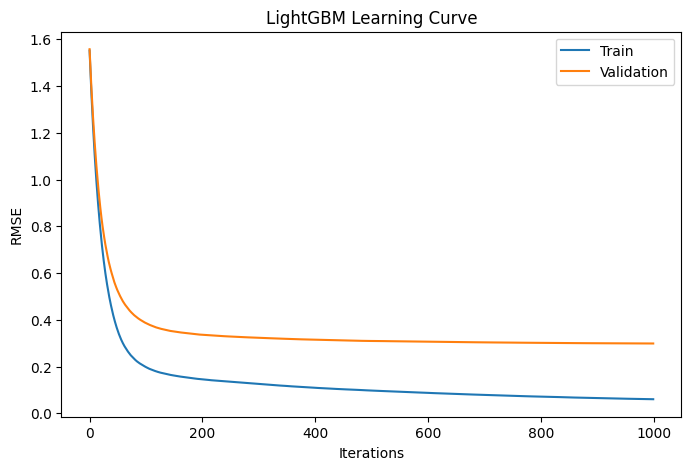

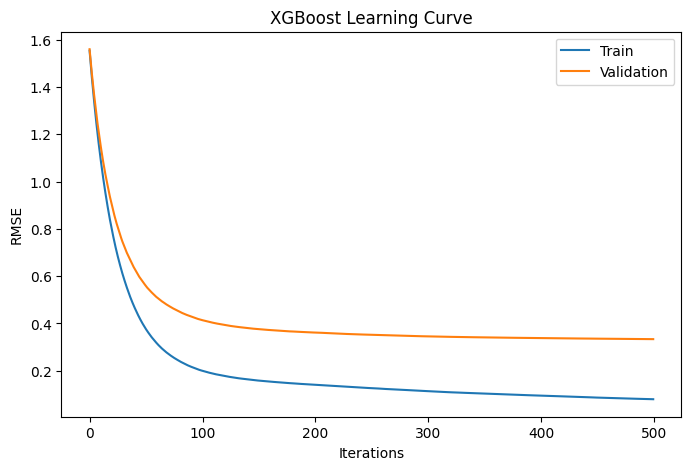

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import xgboost as xgb

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
SEED = 42
N_FOLDS = 5
TARGET = "Addiction_Level"

BASE_FEATURES = [
    "Daily_Usage_Hours",
    "Sleep_Hours",
    "Phone_Checks_Per_Day",
    "Apps_Used_Daily",
    "Time_on_Social_Media",
    "Time_on_Gaming",
]

SELECTED_FEATURES = BASE_FEATURES + [
    "Usage_Sleep_Ratio",
    "Phone_Intensity"
]

# ─────────────────────────────────────────────
# LOAD + FEATURE ENGINEERING
# ─────────────────────────────────────────────
df = pd.read_csv("/content/teen_phone_addiction_dataset.csv")

eps = 1e-6
df["Usage_Sleep_Ratio"] = df["Daily_Usage_Hours"] / (df["Sleep_Hours"] + eps)
df["Phone_Intensity"] = df["Phone_Checks_Per_Day"] * df["Daily_Usage_Hours"]

# ─────────────────────────────────────────────
# TRUE UNSEEN (PSEUDO-EXTERNAL) SPLIT
# ─────────────────────────────────────────────
train_df, external_df = train_test_split(
    df, test_size=0.15, random_state=SEED, shuffle=True
)

train_df = train_df.reset_index(drop=True)
external_df = external_df.reset_index(drop=True)

X = train_df[SELECTED_FEATURES]
y = train_df[TARGET].values

X_ext = external_df[SELECTED_FEATURES]
y_ext = external_df[TARGET].values

# ─────────────────────────────────────────────
# K-FOLD
# ─────────────────────────────────────────────
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

ext_preds_lgb = []
ext_preds_xgb = []

# ─────────────────────────────────────────────
# STORAGE FOR CURVES
# ─────────────────────────────────────────────
lgb_train_curves = []
lgb_val_curves = []

xgb_train_curves = []
xgb_val_curves = []

# ─────────────────────────────────────────────
# TRAIN LOOP
# ─────────────────────────────────────────────
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== FOLD {fold+1} =====")

    X_tr = X.iloc[tr_idx].values
    X_val = X.iloc[val_idx].values
    y_tr = y[tr_idx]
    y_val = y[val_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_ext_scaled = scaler.transform(X_ext)

    # =====================
    # LIGHTGBM
    # =====================
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        random_state=SEED
    )

    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        eval_names=["train", "val"],
        eval_metric="rmse",
        callbacks=[lgb.record_evaluation({})]
    )

    evals = lgb_model.evals_result_

    lgb_train_curves.append(evals["train"]["rmse"])
    lgb_val_curves.append(evals["val"]["rmse"])

    oof_lgb[val_idx] = lgb_model.predict(X_val)
    ext_preds_lgb.append(lgb_model.predict(X_ext_scaled))

    # =====================
    # XGBOOST
    # =====================
    xgb_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        random_state=SEED
    )

    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )

    results = xgb_model.evals_result()

    xgb_train_curves.append(results["validation_0"]["rmse"])
    xgb_val_curves.append(results["validation_1"]["rmse"])

    oof_xgb[val_idx] = xgb_model.predict(X_val)
    ext_preds_xgb.append(xgb_model.predict(X_ext_scaled))

# ─────────────────────────────────────────────
# OOF SCORE (TRUE PERFORMANCE)
# ─────────────────────────────────────────────
def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))

print("\n===== OOF SCORES =====")
print("LGB:", rmse(y, oof_lgb))
print("XGB:", rmse(y, oof_xgb))

# ─────────────────────────────────────────────
# EXTERNAL (TRUE UNSEEN)
# ─────────────────────────────────────────────
ext_lgb = np.mean(ext_preds_lgb, axis=0)
ext_xgb = np.mean(ext_preds_xgb, axis=0)

print("\n===== EXTERNAL VALIDATION =====")
print("LGB:", rmse(y_ext, ext_lgb))
print("XGB:", rmse(y_ext, ext_xgb))

# ─────────────────────────────────────────────
# PLOT CURVES
# ─────────────────────────────────────────────
def plot_curves(train_curves, val_curves, title):
    plt.figure(figsize=(8,5))

    avg_train = np.mean(train_curves, axis=0)
    avg_val = np.mean(val_curves, axis=0)

    plt.plot(avg_train, label="Train")
    plt.plot(avg_val, label="Validation")

    plt.title(title)
    plt.xlabel("Iterations")
    plt.ylabel("RMSE")
    plt.legend()
    plt.show()

plot_curves(lgb_train_curves, lgb_val_curves, "LightGBM Learning Curve")
plot_curves(xgb_train_curves, xgb_val_curves, "XGBoost Learning Curve")